# Skin Disease Classification (VGG19)

### **Colab / Local Environment Setup**
This notebook auto-detects the environment and configures paths accordingly.

- **Google Colab**: Upload your `train` and `test` folders to your Google Drive under `My Drive/Grad proj/`, then the notebook will mount Drive automatically.
- **Local (Windows)**: Ensure your `train` and `test` folders are at `D:\Grad proj\train` and `D:\Grad proj\test`, OR in the same directory as this notebook.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input # Added for preprocessing
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

np.random.seed(42)
tf.random.set_seed(42)

2026-05-21 05:00:34.320084: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779339634.738016      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779339634.855136      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779339635.855725      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779339635.855767      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779339635.855770      57 computation_placer.cc:177] computation placer alr

## 1. Environment Detection & Path Setup

In [18]:
# ============================================================
# ENVIRONMENT DETECTION - works on Colab, Local Windows, Linux
# ============================================================

TRAIN_DIR = None
TEST_DIR = None

# --- Option 1: Google Colab ---
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Check if data is already at /content/train (e.g. uploaded directly)
    if os.path.exists('/content/train'):
        TRAIN_DIR = '/content/train'
        TEST_DIR = '/content/test'
        print('[INFO] Running on Colab - data found at /content/train')
    else:
        # Skip mounting Google Drive as data is expected to come from Kaggle download
        print('[INFO] Skipping Google Drive mount as Kaggle data is used.')

# --- Option 2: Local Windows ---
if TRAIN_DIR is None and os.path.exists(r'D:\Grad proj\train'):
    TRAIN_DIR = r'D:\Grad proj\train'
    TEST_DIR = r'D:\Grad proj\test'
    print('[INFO] Running on Local Windows Environment')

# --- Option 3: Relative to current working directory ---
if TRAIN_DIR is None:
    cwd_train = os.path.join(os.getcwd(), 'train')
    if os.path.exists(cwd_train):
        TRAIN_DIR = cwd_train
        TEST_DIR = os.path.join(os.getcwd(), 'test')
        print(f'[INFO] Found data relative to working directory: {os.getcwd()}')

# --- Option 4: Relative path (last resort) ---
if TRAIN_DIR is None:
    if os.path.exists('train'):
        TRAIN_DIR = 'train'
        TEST_DIR = 'test'
        print('[INFO] Using relative train/test paths')

# The final check for FileNotFoundError is removed here.
# TRAIN_DIR and TEST_DIR will be set by the Kaggle download step (cell 921ad634).

# print(f'\nTrain Dir: {TRAIN_DIR}') # These lines will now execute after Kaggle download
# print(f'Test Dir:  {TEST_DIR}')   # in cell 921ad634.
# if TRAIN_DIR and os.path.exists(TRAIN_DIR):
#     print(f'Train folders: {len(os.listdir(TRAIN_DIR))}')
# else:
#     print('Train directory not yet set or found.')
# if TEST_DIR and os.path.exists(TEST_DIR):
#     print(f'Test folders:  {len(os.listdir(TEST_DIR))}')
# else:
#     print('Test directory not yet set or found.')

[INFO] Skipping Google Drive mount as Kaggle data is used.


## Resources

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shubhamgoel27/dermnet")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/shubhamgoel27/dermnet


### Update Data Directories to use Kaggle Dataset

Now that the Kaggle dataset is downloaded, we will update the `TRAIN_DIR` and `TEST_DIR` variables to point to the `train` and `test` subdirectories within the downloaded path. This ensures that subsequent data loading and processing steps use the Kaggle data.

In [4]:
import os

# Assuming the downloaded dataset has 'train' and 'test' subdirectories
TRAIN_DIR = os.path.join(path, 'train')
TEST_DIR = os.path.join(path, 'test')

print(f'Updated Train Dir: {TRAIN_DIR}')
print(f'Updated Test Dir:  {TEST_DIR}')

# Verify if the directories exist
if not os.path.exists(TRAIN_DIR):
    raise FileNotFoundError(f"Train directory not found at {TRAIN_DIR}")
if not os.path.exists(TEST_DIR):
    raise FileNotFoundError(f"Test directory not found at {TEST_DIR}")

print(f'Train folders: {len(os.listdir(TRAIN_DIR))}')
print(f'Test folders:  {len(os.listdir(TEST_DIR))}')

Updated Train Dir: /kaggle/input/datasets/shubhamgoel27/dermnet/train
Updated Test Dir:  /kaggle/input/datasets/shubhamgoel27/dermnet/test
Train folders: 23
Test folders:  23


## 2. Robust Data Indexing

In [5]:
FOLDER_MAP = {
    'Acne': ['Acne and Rosacea Photos'],
    'Eczema': ['Eczema Photos', 'Atopic Dermatitis Photos'],
    'Psoriasis': ['Psoriasis pictures Lichen Planus and related diseases'],
    'Fungal': ['Tinea Ringworm Candidiasis and other Fungal Infections'],
    'Melanoma': ['Melanoma Skin Cancer Nevi and Moles'],
    'Vitiligo': ['Light Diseases and Disorders of Pigmentation']
}

def build_df(base_dir, mapping):
    data = []
    found_on_disk = os.listdir(base_dir)

    for label, folders in mapping.items():
        for folder in folders:
            # Try case-insensitive matching for Linux/Colab robustness
            match = next((f for f in found_on_disk if f.lower() == folder.lower()), None)

            if match:
                path = os.path.join(base_dir, match)
                imgs = [f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                if imgs:
                    print(f"  [LOADED] {label}: {len(imgs)} images from '{match}'")
                    for img in imgs:
                        data.append({'filename': os.path.join(match, img), 'class': label})
            else:
                print(f"  [MISSING] {folder}")

    return pd.DataFrame(data, columns=['filename', 'class'])

print("Indexing images...")
df_train_full = build_df(TRAIN_DIR, FOLDER_MAP)
df_test = build_df(TEST_DIR, FOLDER_MAP)

if df_train_full.empty:
    print("\nAvailable Folders in Train Dir:", os.listdir(TRAIN_DIR))
    raise ValueError("No images found. Check folder names against the list above.")

# Split 80/20
df_train, df_val = train_test_split(df_train_full, test_size=0.2, stratify=df_train_full['class'], random_state=42)
print(f"\nDataset Stats: Train={len(df_train)}, Val={len(df_val)}, Test={len(df_test)}")

Indexing images...
  [LOADED] Acne: 840 images from 'Acne and Rosacea Photos'
  [LOADED] Eczema: 1235 images from 'Eczema Photos'
  [LOADED] Eczema: 489 images from 'Atopic Dermatitis Photos'
  [LOADED] Psoriasis: 1405 images from 'Psoriasis pictures Lichen Planus and related diseases'
  [LOADED] Fungal: 1300 images from 'Tinea Ringworm Candidiasis and other Fungal Infections'
  [LOADED] Melanoma: 463 images from 'Melanoma Skin Cancer Nevi and Moles'
  [LOADED] Vitiligo: 568 images from 'Light Diseases and Disorders of Pigmentation'
  [LOADED] Acne: 312 images from 'Acne and Rosacea Photos'
  [LOADED] Eczema: 309 images from 'Eczema Photos'
  [LOADED] Eczema: 123 images from 'Atopic Dermatitis Photos'
  [LOADED] Psoriasis: 352 images from 'Psoriasis pictures Lichen Planus and related diseases'
  [LOADED] Fungal: 325 images from 'Tinea Ringworm Candidiasis and other Fungal Infections'
  [LOADED] Melanoma: 116 images from 'Melanoma Skin Cancer Nevi and Moles'
  [LOADED] Vitiligo: 143 ima

### 4.1 Minority-Targeted Oversampling

Given the class imbalance observed, we will implement minority-targeted oversampling using `sklearn.utils.resample` to balance the training dataset. This will ensure that minority classes like 'Melanoma' and 'Vitiligo' receive more representation during training, helping the model learn more effectively from these critical classes.

In [6]:
from sklearn.utils import resample

# Define minority classes based on EDA observations
minority_classes = ['Melanoma', 'Vitiligo']

# Find the count of the majority class in the original df_train
majority_count = df_train['class'].value_counts().max()
print(f"Majority class count: {majority_count}")

# Separate majority and minority classes
df_train_majority = df_train[~df_train['class'].isin(minority_classes)]
df_train_minority = df_train[df_train['class'].isin(minority_classes)]

# Oversample each minority class to match the majority_count
df_train_oversampled = []
for m_class in minority_classes:
    df_minority_class = df_train[df_train['class'] == m_class]
    df_oversampled_class = resample(df_minority_class,
                                    replace=True,     # sample with replacement
                                    n_samples=majority_count, # to match majority class
                                    random_state=42)  # for reproducibility
    df_train_oversampled.append(df_oversampled_class)

# Concatenate the oversampled minority classes with the original majority classes
df_train_balanced = pd.concat([df_train_majority] + df_train_oversampled)

# Shuffle the balanced dataframe
df_train_balanced = df_train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nOriginal Training Set Size: {len(df_train)}")
print(f"Balanced Training Set Size: {len(df_train_balanced)}")

print("\nNew Class Distribution in Balanced Training Set:")
display(df_train_balanced['class'].value_counts().to_frame())


Majority class count: 1379

Original Training Set Size: 5040
Balanced Training Set Size: 6973

New Class Distribution in Balanced Training Set:


,count
class,
Vitiligo,1379
Eczema,1379
Melanoma,1379
Psoriasis,1124
Fungal,1040
Acne,672


## 4. Exploratory Data Analysis (EDA)

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Define class names here as it's needed for EDA before model training
class_names = sorted(df_train_full['class'].unique())
print(f"Detected Classes: {class_names}")

Detected Classes: ['Acne', 'Eczema', 'Fungal', 'Melanoma', 'Psoriasis', 'Vitiligo']


### Class Distribution

/tmp/ipykernel_57/1510794164.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='class', data=df_train_full, order=class_names, palette='viridis')
/tmp/ipykernel_57/1510794164.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='class', data=df_train, order=class_names, palette='viridis')
/tmp/ipykernel_57/1510794164.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='class', data=df_val, order=class_names, palette='viridis')
/tmp/ipykernel_57/1510794164.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is dep

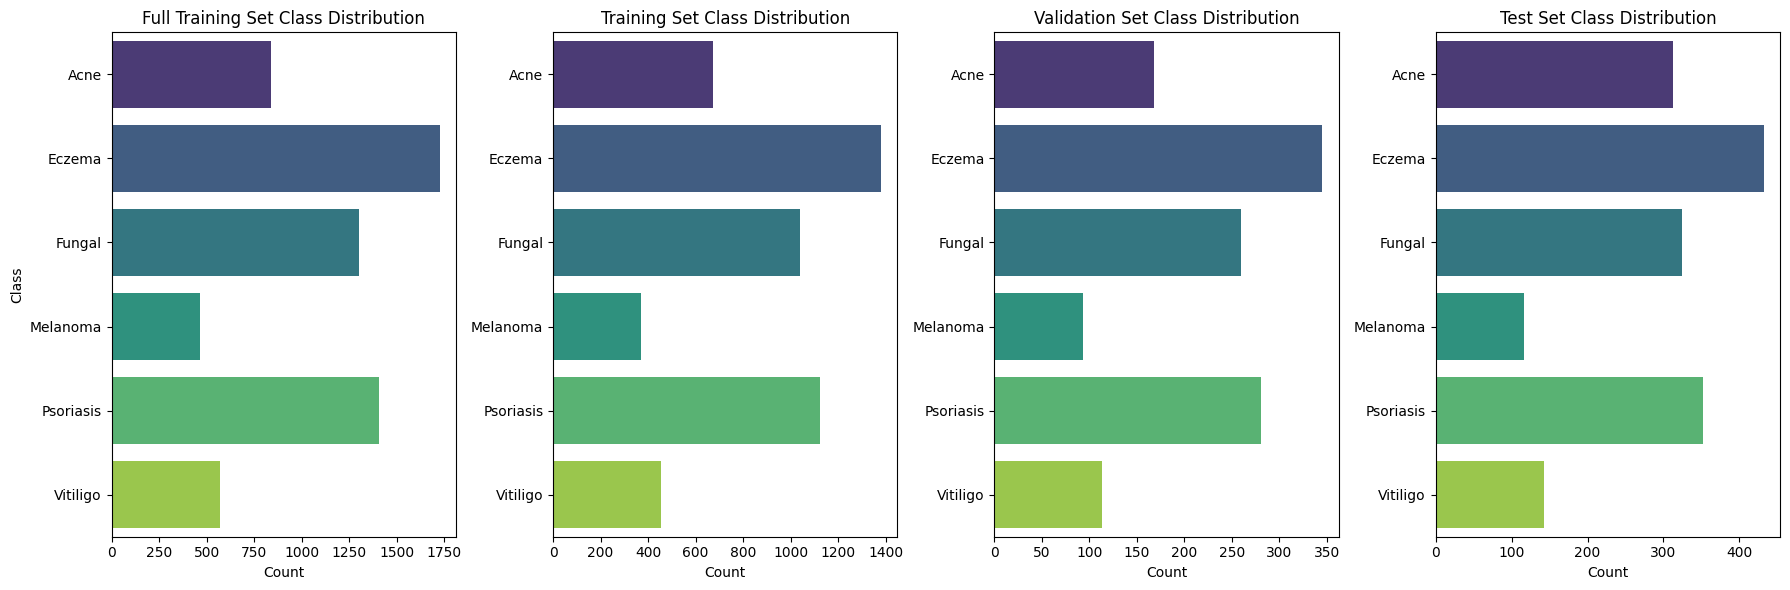

In [8]:
# Plot class distribution for full training, training, validation, and test sets
plt.figure(figsize=(18, 6))

plt.subplot(1, 4, 1)
sns.countplot(y='class', data=df_train_full, order=class_names, palette='viridis')
plt.title('Full Training Set Class Distribution')
plt.xlabel('Count')
plt.ylabel('Class')

plt.subplot(1, 4, 2)
sns.countplot(y='class', data=df_train, order=class_names, palette='viridis')
plt.title('Training Set Class Distribution')
plt.xlabel('Count')
plt.ylabel('')

plt.subplot(1, 4, 3)
sns.countplot(y='class', data=df_val, order=class_names, palette='viridis')
plt.title('Validation Set Class Distribution')
plt.xlabel('Count')
plt.ylabel('')

plt.subplot(1, 4, 4)
sns.countplot(y='class', data=df_test, order=class_names, palette='viridis')
plt.title('Test Set Class Distribution')
plt.xlabel('Count')
plt.ylabel('')

plt.tight_layout()
plt.show()

### Sample Images per Class

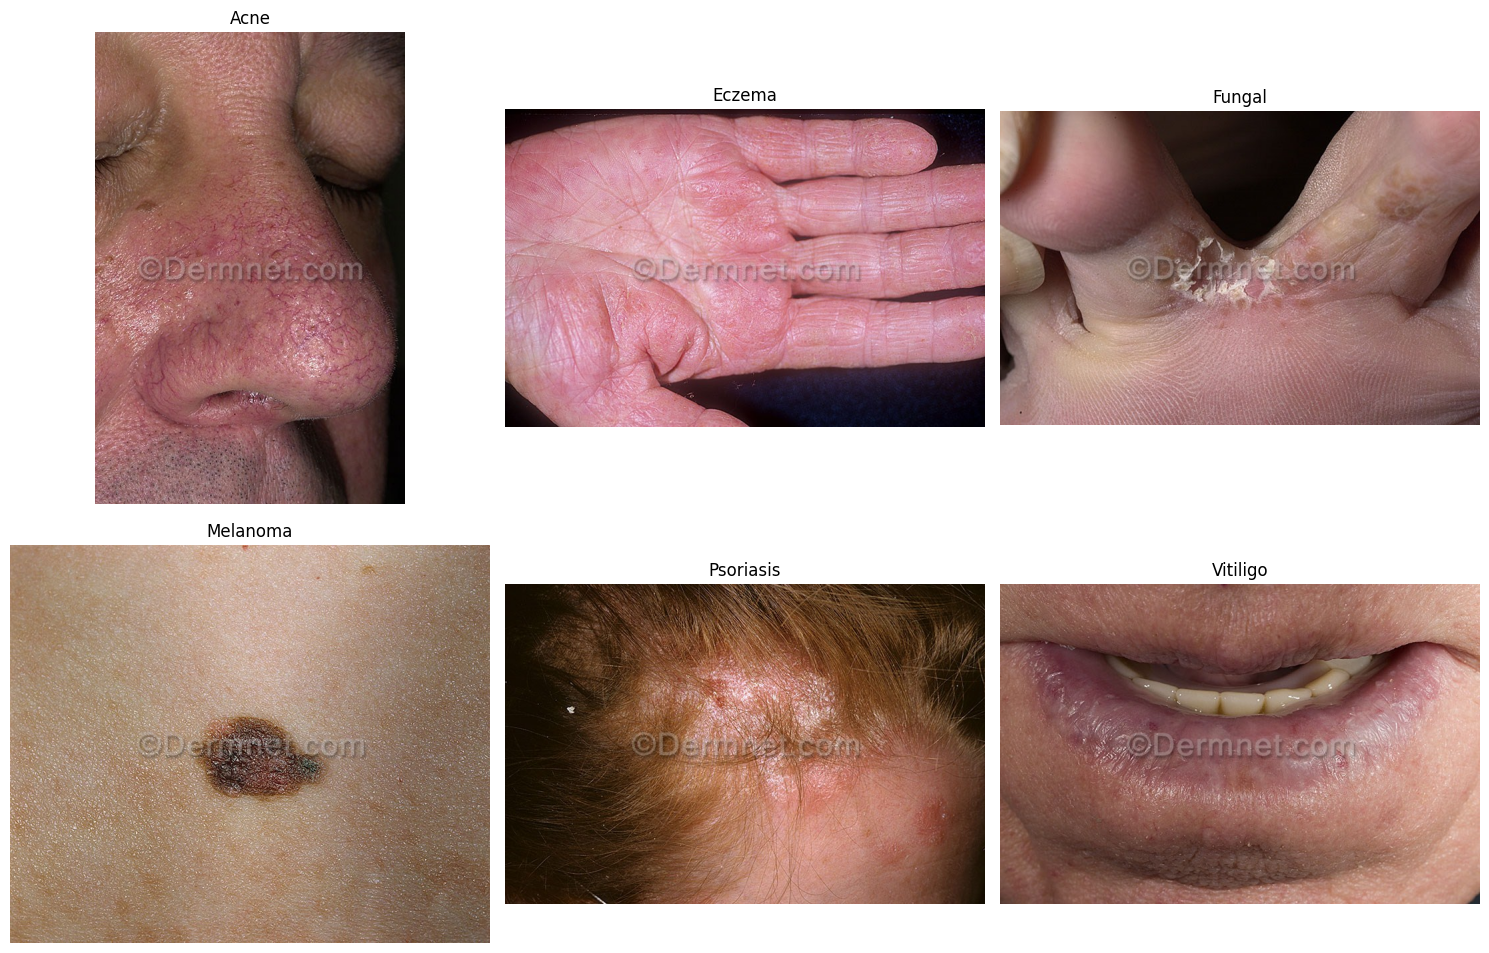

In [9]:
# Display a sample image for each class
plt.figure(figsize=(15, 10))
for i, class_name in enumerate(class_names):
    plt.subplot(2, 3, i + 1)
    # Get a random image path for the current class from the training set
    sample_img_path = df_train[df_train['class'] == class_name].sample(1)['filename'].iloc[0]
    full_img_path = os.path.join(TRAIN_DIR, sample_img_path)
    img = Image.open(full_img_path)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')
plt.tight_layout()
plt.show()

### Interpreting Class Distribution

From the generated plots, it's evident that there's a significant class imbalance across the dataset. Some classes like 'Eczema' and 'Fungal' have a much larger number of samples compared to 'Melanoma' and 'Vitiligo'. This imbalance is consistent across the full training, training, validation, and test sets.

This is a critical observation, as imbalanced datasets can lead to models that perform well on majority classes but poorly on minority classes. The model might become biased towards the more frequent classes, resulting in lower recall and F1-scores for the under-represented diseases.

### Quantifying Class Imbalance

To better understand the extent of this imbalance, let's calculate the exact counts and percentages for each class in the full training dataset.

In [10]:
print('Class Distribution in Full Training Set:')
class_counts = df_train_full['class'].value_counts()
class_percentages = df_train_full['class'].value_counts(normalize=True) * 100

class_distribution_df = pd.DataFrame({
    'Count': class_counts,
    'Percentage': class_percentages
}).sort_values(by='Count', ascending=False)

display(class_distribution_df)


Class Distribution in Full Training Set:


,Count,Percentage
class,,
Eczema,1724,27.365079
Psoriasis,1405,22.301587
Fungal,1300,20.634921
Acne,840,13.333333
Vitiligo,568,9.015873
Melanoma,463,7.349206


### Dataset Problems and Solutions

**Identified Problem: Class Imbalance**

The numerical breakdown clearly shows that 'Psoriasis', 'Eczema', and 'Fungal' are the majority classes, while 'Melanoma' and 'Vitiligo' are significantly under-represented. This imbalance can severely impact the model's ability to accurately predict minority classes.

**Potential Solutions:**

1.  **Resampling Techniques:**
    *   **Oversampling minority classes:** Duplicating samples from minority classes (e.g., using `ImageDataGenerator`'s `rotation_range`, `zoom_range` to create new variations, or techniques like SMOTE).
    *   **Undersampling majority classes:** Randomly removing samples from majority classes (use with caution to avoid losing valuable information).
2.  **Class Weighting:** As already implemented, assigning higher weights to minority classes during training helps the model pay more attention to their errors. This was done using `compute_class_weight`.
3.  **Data Augmentation:** While already in use, more aggressive augmentation for minority classes can help create more diverse samples.
4.  **Evaluation Metrics:** Focus on metrics like F1-score, precision, recall, and AUC-ROC, especially per-class, rather than just overall accuracy, as accuracy can be misleading on imbalanced datasets.

## 3. Training & Architecture

In [11]:
IMG_SIZE = (224, 224) # Changed from (180, 180) to (224, 224)
BATCH_SIZE = 32

# Generators - Updated with preprocessing_function and stronger augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40, # Stronger augmentation
    zoom_range=0.25,   # Stronger augmentation
    horizontal_flip=True,
    vertical_flip=True, # Stronger augmentation
    brightness_range=[0.8, 1.2], # Stronger augmentation
    shear_range=0.15, # Stronger augmentation
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_dataframe(df_train, directory=TRAIN_DIR, x_col='filename', y_col='class', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')
val_gen = val_test_datagen.flow_from_dataframe(df_val, directory=TRAIN_DIR, x_col='filename', y_col='class', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
test_gen = val_test_datagen.flow_from_dataframe(df_test, directory=TEST_DIR, x_col='filename', y_col='class', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

# Weights & Model
class_names = np.array(sorted(df_train['class'].unique())) # Convert to numpy array
weights = compute_class_weight(class_weight='balanced', classes=class_names, y=df_train['class'])
weight_dict = dict(enumerate(weights))

vgg = VGG19(weights='imagenet', include_top=False, input_shape=(224, 224, 3)) # Updated input_shape
vgg.trainable = False
x = GlobalAveragePooling2D()(vgg.output)
x = Dense(512, activation='relu', kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x) # Changed from 0.5 to 0.4
x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x) # Changed from 0.5 to 0.3
out = Dense(len(class_names), activation='softmax')(x)

model = Model(inputs=vgg.input, outputs=out)
model.compile(optimizer=Adam(1e-3), loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), metrics=['accuracy']) # Added label_smoothing

callbacks = [
    ModelCheckpoint('best_skin_model.h5', save_best_only=True, monitor='val_loss'), # Changed monitor to 'val_loss'
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

print("\n--- Training Phase 1: Classification Head ---")
model.fit(train_gen, validation_data=val_gen, epochs=25, class_weight=weight_dict, callbacks=callbacks)

print("\n--- Training Phase 2: Fine-Tuning ---")
# Broader Fine-Tuning: Unfreeze all layers in block4 and block5
vgg.trainable = True
for layer in vgg.layers:
    layer.trainable = 'block4' in layer.name or 'block5' in layer.name
model.compile(optimizer=Adam(1e-5), loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), metrics=['accuracy']) # Added label_smoothing
model.fit(train_gen, validation_data=val_gen, epochs=15, class_weight=weight_dict, callbacks=callbacks)

Found 5040 validated image filenames belonging to 6 classes.
Found 1260 validated image filenames belonging to 6 classes.
Found 1680 validated image filenames belonging to 6 classes.


I0000 00:00:1779339703.000280      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779339703.006658      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- Training Phase 1: Classification Head ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25


...

158/158 ━━━━━━━━━━━━━━━━━━━━ 92s 583ms/step - accuracy: 0.6505 - loss: 1.2964 - val_accuracy: 0.6167 - val_loss: 1.4469 - learning_rate: 1.0000e-05
Epoch 8/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 93s 587ms/step - accuracy: 0.6369 - loss: 1.2957 - val_accuracy: 0.5952 - val_loss: 1.4700 - learning_rate: 1.0000e-05
Epoch 9/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 533ms/step - accuracy: 0.6655 - loss: 1.2504

158/158 ━━━━━━━━━━━━━━━━━━━━ 94s 591ms/step - accuracy: 0.6655 - loss: 1.2504 - val_accuracy: 0.6198 - val_loss: 1.4275 - learning_rate: 1.0000e-05
Epoch 10/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 93s 584ms/step - accuracy: 0.6888 - loss: 1.2339 - val_accuracy: 0.5952 - val_loss: 1.4801 - learning_rate: 1.0000e-05
Epoch 11/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 93s 588ms/step - accuracy: 0.6773 - loss: 1.2366 - val_accuracy: 0.6238 - val_loss: 1.4342 - learning_rate: 1.0000e-05
Epoch 12/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 92s 582ms/step - accuracy: 0.7024 - loss: 1.1906 - val_accuracy: 0.6206 - val_loss: 1.4360 - learning_rate: 1.0000e-05
Epoch 13/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 533ms/step - accuracy: 0.6960 - loss: 1.1889

158/158 ━━━━━━━━━━━━━━━━━━━━ 94s 591ms/step - accuracy: 0.6961 - loss: 1.1888 - val_accuracy: 0.6341 - val_loss: 1.4044 - learning_rate: 5.0000e-06
Epoch 14/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 584ms/step - accuracy: 0.7169 - loss: 1.1728

158/158 ━━━━━━━━━━━━━━━━━━━━ 102s 642ms/step - accuracy: 0.7169 - loss: 1.1728 - val_accuracy: 0.6302 - val_loss: 1.4011 - learning_rate: 5.0000e-06
Epoch 15/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 550ms/step - accuracy: 0.7245 - loss: 1.1574

158/158 ━━━━━━━━━━━━━━━━━━━━ 96s 607ms/step - accuracy: 0.7246 - loss: 1.1573 - val_accuracy: 0.6492 - val_loss: 1.3677 - learning_rate: 5.0000e-06


## 5. Stratified K-Fold Cross-Validation and Ensemble Training

To ensure robust model evaluation and improve generalization, we will implement Stratified K-Fold Cross-Validation. This approach divides the data into `k` folds, training on `k-1` folds and validating on the remaining fold, repeating `k` times. Stratification ensures that each fold maintains the same class distribution as the original dataset.

We will also introduce a `heavy_datagen` for more aggressive augmentation, particularly beneficial for the oversampled minority classes. Each fold will train a fresh VGG19 model, and predictions from all folds will be ensembled to provide a final, more reliable prediction.


--- Fold 1/5 ---
Fold 1 Training Set Size (balanced): 6973
Fold 1 Validation Set Size: 1260
Found 6973 validated image filenames belonging to 6 classes.
Found 1260 validated image filenames belonging to 6 classes.

--- Training Phase 1: Classification Head (Fold {fold+1}) ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 143s 633ms/step - accuracy: 0.3189 - loss: 2.9379 - val_accuracy: 0.3865 - val_loss: 2.5702 - learning_rate: 0.0010
Epoch 2/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 124s 566ms/step - accuracy: 0.4250 - loss: 2.3990 - val_accuracy: 0.4302 - val_loss: 2.3850 - learning_rate: 0.0010
Epoch 3/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 125s 573ms/step - accuracy: 0.4578 - loss: 2.2284 - val_accuracy: 0.4222 - val_loss: 2.2629 - learning_rate: 0.0010
Epoch 4/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 125s 572ms/step - accuracy: 0.4853 - loss: 2.0885 - val_accuracy: 0.4444 - val_loss: 2.1009 - learning_rate: 0.0010
Epoch 5/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 124s 568ms/step - accuracy: 0.5052 - loss: 1.9830 - val_accuracy: 0.4635 - val_loss: 2.0286 - learning_rate: 0.0010
Epoch 6/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 126s 578ms/step - accuracy: 0.5088 - loss: 1.9055 - val_accuracy: 0.4286 - val_loss: 2.0149 - learning_rate: 0.0010
Epoch 7/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 125s 575ms/step - accura

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 132s 582ms/step - accuracy: 0.3277 - loss: 2.9401 - val_accuracy: 0.4008 - val_loss: 2.4799 - learning_rate: 0.0010
Epoch 2/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 125s 574ms/step - accuracy: 0.4150 - loss: 2.4101 - val_accuracy: 0.4444 - val_loss: 2.2673 - learning_rate: 0.0010
Epoch 3/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 124s 566ms/step - accuracy: 0.4545 - loss: 2.2198 - val_accuracy: 0.4492 - val_loss: 2.1660 - learning_rate: 0.0010
Epoch 4/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 125s 571ms/step - accuracy: 0.4827 - loss: 2.0853 - val_accuracy: 0.4111 - val_loss: 2.1384 - learning_rate: 0.0010
Epoch 5/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 124s 569ms/step - accuracy: 0.4846 - loss: 1.9917 - val_accuracy: 0.4833 - val_loss: 1.9481 - learning_rate: 0.0010
Epoch 6/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 124s 569ms/step - accuracy: 0.5038 - loss: 1.9103 - val_accuracy: 0.4690 - val_loss: 1.9392 - learning_rate: 0.0010
Epoch 7/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 124s 569ms/step - accura

...

Epoch 1/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 131s 580ms/step - accuracy: 0.3081 - loss: 2.9802 - val_accuracy: 0.4048 - val_loss: 2.4615 - learning_rate: 0.0010
Epoch 2/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 123s 561ms/step - accuracy: 0.4045 - loss: 2.4187 - val_accuracy: 0.3913 - val_loss: 2.4099 - learning_rate: 0.0010
Epoch 3/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 120s 552ms/step - accuracy: 0.4536 - loss: 2.2312 - val_accuracy: 0.4071 - val_loss: 2.2436 - learning_rate: 0.0010
Epoch 4/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 122s 558ms/step - accuracy: 0.4900 - loss: 2.0851 - val_accuracy: 0.4230 - val_loss: 2.1530 - learning_rate: 0.0010
Epoch 5/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 121s 556ms/step - accuracy: 0.4999 - loss: 1.9854 - val_accuracy: 0.4452 - val_loss: 2.0346 - learning_rate: 0.0010
Epoch 6/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 121s 556ms/step - accuracy: 0.5175 - loss: 1.8961 - val_accuracy: 0.4595 - val_loss: 1.9897 - learning_rate: 0.0010
Epoch 7/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 121s 553ms/step - accura

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 134s 590ms/step - accuracy: 0.3301 - loss: 2.9258 - val_accuracy: 0.4103 - val_loss: 2.5348 - learning_rate: 0.0010
Epoch 2/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 127s 580ms/step - accuracy: 0.4175 - loss: 2.4060 - val_accuracy: 0.4222 - val_loss: 2.3378 - learning_rate: 0.0010
Epoch 3/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 125s 572ms/step - accuracy: 0.4603 - loss: 2.2209 - val_accuracy: 0.4278 - val_loss: 2.2050 - learning_rate: 0.0010
Epoch 4/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 127s 581ms/step - accuracy: 0.4791 - loss: 2.0696 - val_accuracy: 0.4437 - val_loss: 2.1051 - learning_rate: 0.0010
Epoch 5/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 123s 564ms/step - accuracy: 0.5023 - loss: 1.9783 - val_accuracy: 0.4532 - val_loss: 2.0540 - learning_rate: 0.0010
Epoch 6/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 124s 569ms/step - accuracy: 0.5153 - loss: 1.8992 - val_accuracy: 0.4571 - val_loss: 1.9512 - learning_rate: 0.0010
Epoch 7/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 124s 567ms/step - accura

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 146s 647ms/step - accuracy: 0.3128 - loss: 2.9631 - val_accuracy: 0.3984 - val_loss: 2.5212 - learning_rate: 0.0010
Epoch 2/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 126s 577ms/step - accuracy: 0.4174 - loss: 2.4164 - val_accuracy: 0.4190 - val_loss: 2.4370 - learning_rate: 0.0010
Epoch 3/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 126s 579ms/step - accuracy: 0.4441 - loss: 2.2456 - val_accuracy: 0.4508 - val_loss: 2.2524 - learning_rate: 0.0010
Epoch 4/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 126s 576ms/step - accuracy: 0.4837 - loss: 2.0938 - val_accuracy: 0.4579 - val_loss: 2.1651 - learning_rate: 0.0010
Epoch 5/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 126s 577ms/step - accuracy: 0.4823 - loss: 2.0126 - val_accuracy: 0.4571 - val_loss: 2.0482 - learning_rate: 0.0010
Epoch 6/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 127s 581ms/step - accuracy: 0.4972 - loss: 1.9303 - val_accuracy: 0.4786 - val_loss: 1.9335 - learning_rate: 0.0010
Epoch 7/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 125s 572ms/step - accura

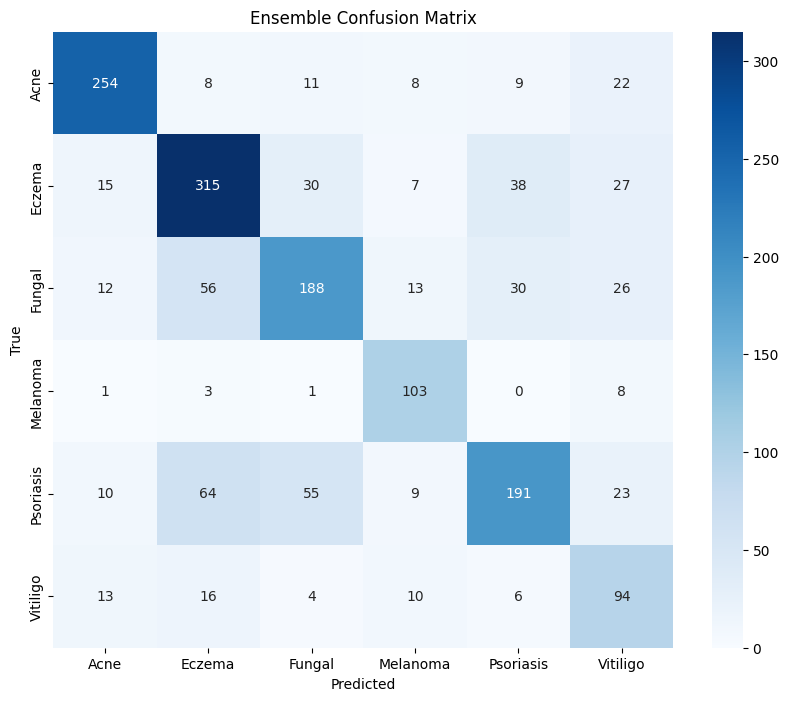

In [12]:
from sklearn.model_selection import StratifiedKFold

# Define the heavy augmentation ImageDataGenerator
heavy_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=60,
    zoom_range=0.35,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.7, 1.3],
    shear_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    fill_mode='nearest'
)

# The validation/test datagen remains the same
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Initialize Stratified K-Fold
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

fold_predictions = []
fold_histories = []

# Re-define class_names based on the full training set for consistent indexing
class_names = sorted(df_train_full['class'].unique())
num_classes = len(class_names)

# Callbacks for training
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

for fold, (train_idx, val_idx) in enumerate(skf.split(df_train_full['filename'], df_train_full['class'])):
    print(f"\n--- Fold {fold+1}/{n_splits} ---")

    # Split data for the current fold
    df_tr = df_train_full.iloc[train_idx].reset_index(drop=True)
    df_vl = df_train_full.iloc[val_idx].reset_index(drop=True)

    # Apply minority oversampling to the training data of the current fold
    df_tr_majority = df_tr[~df_tr['class'].isin(minority_classes)]
    df_tr_minority = df_tr[df_tr['class'].isin(minority_classes)]

    df_tr_oversampled = []
    for m_class in minority_classes:
        df_m_class = df_tr[df_tr['class'] == m_class]
        if not df_m_class.empty:
            df_oversampled_m_class = resample(df_m_class,
                                            replace=True,
                                            n_samples=majority_count, # use global majority count
                                            random_state=42)
            df_tr_oversampled.append(df_oversampled_m_class)

    df_tr_balanced_fold = pd.concat([df_tr_majority] + df_tr_oversampled)
    df_tr_balanced_fold = df_tr_balanced_fold.sample(frac=1, random_state=42).reset_index(drop=True)

    print(f"Fold {fold+1} Training Set Size (balanced): {len(df_tr_balanced_fold)}")
    print(f"Fold {fold+1} Validation Set Size: {len(df_vl)}")

    # Create generators for the current fold
    train_gen_fold = heavy_datagen.flow_from_dataframe(
        df_tr_balanced_fold,
        directory=TRAIN_DIR,
        x_col='filename',
        y_col='class',
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical'
    )

    val_gen_fold = val_test_datagen.flow_from_dataframe(
        df_vl,
        directory=TRAIN_DIR,
        x_col='filename',
        y_col='class',
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )

    # Recompute class weights for the balanced training data of the current fold
    fold_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(df_tr_balanced_fold['class']),
        y=df_tr_balanced_fold['class']
    )
    fold_weight_dict = dict(zip(np.unique(df_tr_balanced_fold['class']), fold_weights))

    # Build a fresh VGG19 model for the current fold
    vgg = VGG19(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    vgg.trainable = False

    x = GlobalAveragePooling2D()(vgg.output)
    x = Dense(512, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    out = Dense(num_classes, activation='softmax')(x)

    model_fold = Model(inputs=vgg.input, outputs=out)
    model_fold.compile(optimizer=Adam(1e-3), loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), metrics=['accuracy'])

    checkpoint_callback = ModelCheckpoint(f'best_model_fold{fold+1}.keras', save_best_only=True, monitor='val_loss')
    fold_callbacks = callbacks + [checkpoint_callback]

    print("\n--- Training Phase 1: Classification Head (Fold {fold+1}) ---")
    history1 = model_fold.fit(train_gen_fold, validation_data=val_gen_fold, epochs=25, class_weight=fold_weight_dict, callbacks=fold_callbacks)

    print("\n--- Training Phase 2: Fine-Tuning (Fold {fold+1}) ---")
    # Unfreeze block4 and block5
    for layer in vgg.layers:
        if 'block4' in layer.name or 'block5' in layer.name:
            layer.trainable = True
        else:
            layer.trainable = False

    model_fold.compile(optimizer=Adam(1e-5), loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), metrics=['accuracy'])
    history2 = model_fold.fit(train_gen_fold, validation_data=val_gen_fold, epochs=15, class_weight=fold_weight_dict, callbacks=fold_callbacks)

    fold_histories.append({'phase1': history1.history, 'phase2': history2.history})

    # Load the best model weights for prediction
    model_fold.load_weights(f'best_model_fold{fold+1}.keras')

    # Evaluate on the test set (using the global test_gen)
    print(f"\n--- Evaluating Fold {fold+1} on Test Set ---")
    test_loss, test_acc = model_fold.evaluate(test_gen, verbose=0)
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

    # Store predictions for ensembling
    fold_preds = model_fold.predict(test_gen)
    fold_predictions.append(fold_preds)

    # Print classification report for the fold
    y_true_test = test_gen.classes
    y_pred_fold = np.argmax(fold_preds, axis=1)
    print(f"\nClassification Report for Fold {fold+1}:")
    print(classification_report(y_true_test, y_pred_fold, target_names=class_names))

# --- Ensemble Predictions ---
print("\n--- Averaging Fold Predictions for Ensemble ---")
ensemble_preds = np.mean(fold_predictions, axis=0)
ensemble_y_pred = np.argmax(ensemble_preds, axis=1)

print("\n--- Ensemble Classification Report ---")
print(classification_report(y_true_test, ensemble_y_pred, target_names=class_names))

# Ensemble Confusion Matrix
ensemble_cm = confusion_matrix(y_true_test, ensemble_y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(ensemble_cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title('Ensemble Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


## 4. Evaluation

53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 215ms/step

Classification Report:
              precision    recall  f1-score   support

        Acne       0.80      0.83      0.82       312
      Eczema       0.70      0.60      0.65       432
      Fungal       0.59      0.66      0.62       325
    Melanoma       0.61      0.88      0.72       116
   Psoriasis       0.66      0.47      0.55       352
    Vitiligo       0.46      0.64      0.53       143

    accuracy                           0.65      1680
   macro avg       0.64      0.68      0.65      1680
weighted avg       0.66      0.65      0.65      1680



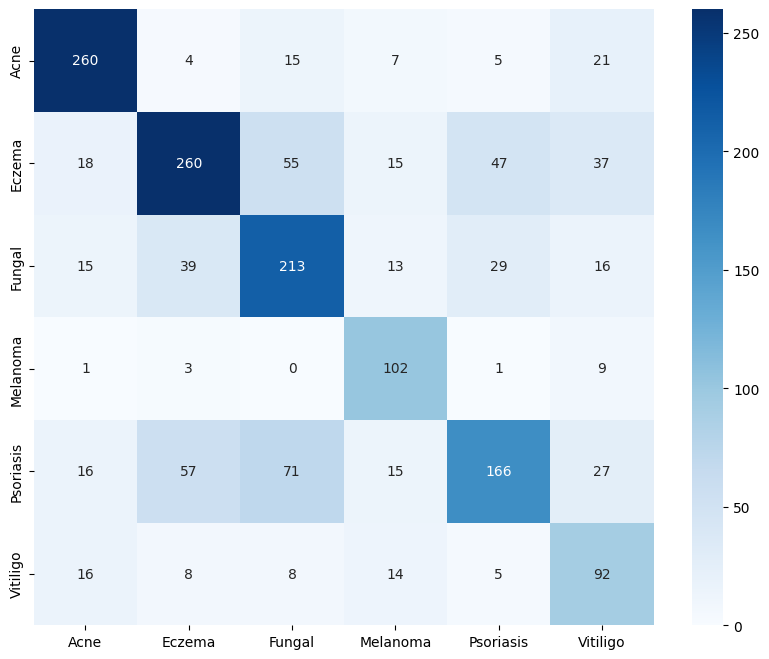

In [13]:
Y_pred = model.predict(test_gen)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_gen.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.show()

## 5. Test-Time Augmentation (TTA)


--- Performing Test-Time Augmentation (TTA) on Ensemble Models ---

Loading and applying TTA for Fold 1 model...
Found 1680 validated image filenames belonging to 6 classes.
  TTA Pass 1/7 for Fold 1


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


53/53 ━━━━━━━━━━━━━━━━━━━━ 28s 505ms/step
  TTA Pass 2/7 for Fold 1
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 499ms/step
  TTA Pass 3/7 for Fold 1
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 500ms/step
  TTA Pass 4/7 for Fold 1
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 501ms/step
  TTA Pass 5/7 for Fold 1
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 497ms/step
  TTA Pass 6/7 for Fold 1
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 500ms/step
  TTA Pass 7/7 for Fold 1
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 501ms/step

Loading and applying TTA for Fold 2 model...
Found 1680 validated image filenames belonging to 6 classes.
  TTA Pass 1/7 for Fold 2


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


53/53 ━━━━━━━━━━━━━━━━━━━━ 28s 506ms/step
  TTA Pass 2/7 for Fold 2
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 502ms/step
  TTA Pass 3/7 for Fold 2
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 503ms/step
  TTA Pass 4/7 for Fold 2
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 510ms/step
  TTA Pass 5/7 for Fold 2
53/53 ━━━━━━━━━━━━━━━━━━━━ 26s 496ms/step
  TTA Pass 6/7 for Fold 2
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 505ms/step
  TTA Pass 7/7 for Fold 2
53/53 ━━━━━━━━━━━━━━━━━━━━ 26s 494ms/step

Loading and applying TTA for Fold 3 model...
Found 1680 validated image filenames belonging to 6 classes.
  TTA Pass 1/7 for Fold 3


...

53/53 ━━━━━━━━━━━━━━━━━━━━ 28s 511ms/step
  TTA Pass 2/7 for Fold 3
53/53 ━━━━━━━━━━━━━━━━━━━━ 26s 492ms/step
  TTA Pass 3/7 for Fold 3
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 499ms/step
  TTA Pass 4/7 for Fold 3
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 498ms/step
  TTA Pass 5/7 for Fold 3
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 501ms/step
  TTA Pass 6/7 for Fold 3
53/53 ━━━━━━━━━━━━━━━━━━━━ 26s 493ms/step
  TTA Pass 7/7 for Fold 3
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 501ms/step

Loading and applying TTA for Fold 4 model...
Found 1680 validated image filenames belonging to 6 classes.
  TTA Pass 1/7 for Fold 4


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


53/53 ━━━━━━━━━━━━━━━━━━━━ 28s 502ms/step
  TTA Pass 2/7 for Fold 4
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 512ms/step
  TTA Pass 3/7 for Fold 4
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 504ms/step
  TTA Pass 4/7 for Fold 4
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 500ms/step
  TTA Pass 5/7 for Fold 4
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 498ms/step
  TTA Pass 6/7 for Fold 4
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 504ms/step
  TTA Pass 7/7 for Fold 4
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 504ms/step

Loading and applying TTA for Fold 5 model...
Found 1680 validated image filenames belonging to 6 classes.
  TTA Pass 1/7 for Fold 5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


53/53 ━━━━━━━━━━━━━━━━━━━━ 28s 507ms/step
  TTA Pass 2/7 for Fold 5
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 502ms/step
  TTA Pass 3/7 for Fold 5
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 503ms/step
  TTA Pass 4/7 for Fold 5
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 499ms/step
  TTA Pass 5/7 for Fold 5
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 503ms/step
  TTA Pass 6/7 for Fold 5
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 504ms/step
  TTA Pass 7/7 for Fold 5
53/53 ━━━━━━━━━━━━━━━━━━━━ 26s 494ms/step

--- TTA Ensemble Classification Report ---
              precision    recall  f1-score   support

        Acne       0.80      0.85      0.82       312
      Eczema       0.74      0.66      0.70       432
      Fungal       0.68      0.61      0.64       325
    Melanoma       0.77      0.85      0.81       116
   Psoriasis       0.66      0.63      0.64       352
    Vitiligo       0.50      0.73      0.59       143

    accuracy                           0.70      1680
   macro avg       0.69      0.72      0.70      1680
weighted avg      

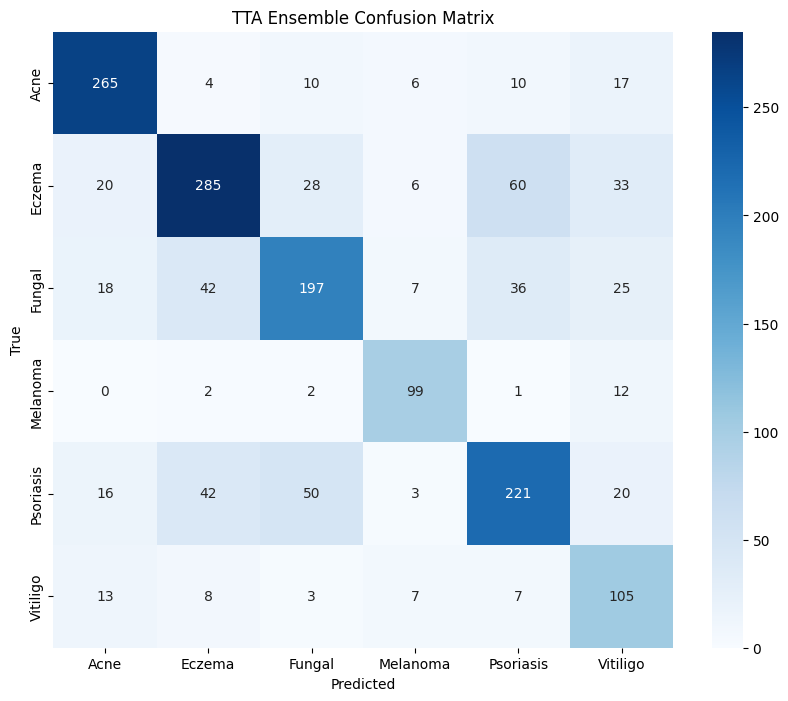

In [14]:
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, f1_score, accuracy_score

print("\n--- Performing Test-Time Augmentation (TTA) on Ensemble Models ---")

# Number of TTA passes per model
TTA_PASSES = 7

all_tta_fold_predictions = []

for fold in range(n_splits):
    print(f"\nLoading and applying TTA for Fold {fold+1} model...")
    # Load the best model for the current fold
    model_path = f'best_model_fold{fold+1}.keras'
    try:
        fold_model = load_model(model_path)
    except Exception as e:
        print(f"Error loading model {model_path}: {e}")
        continue

    # Create a TTA generator for the test set using heavy_datagen
    # Ensure shuffle=False for consistent order during TTA
    tta_gen = heavy_datagen.flow_from_dataframe(
        df_test,
        directory=TEST_DIR,
        x_col='filename',
        y_col='class',
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )

    # Perform TTA passes for the current fold's model
    fold_tta_predictions = []
    for i in range(TTA_PASSES):
        print(f"  TTA Pass {i+1}/{TTA_PASSES} for Fold {fold+1}")
        # Reset generator to ensure fresh augmentation for each pass
        tta_gen.reset()
        fold_tta_predictions.append(fold_model.predict(tta_gen))

    # Average predictions for the current fold's TTA passes
    averaged_fold_tta_preds = np.mean(fold_tta_predictions, axis=0)
    all_tta_fold_predictions.append(averaged_fold_tta_preds)

# Average all TTA predictions across all folds
tta_ensemble_preds = np.mean(all_tta_fold_predictions, axis=0)
tta_ensemble_y_pred = np.argmax(tta_ensemble_preds, axis=1)

y_true_test = test_gen.classes # Ground truth labels

print("\n--- TTA Ensemble Classification Report ---")
tta_ensemble_report = classification_report(y_true_test, tta_ensemble_y_pred, target_names=class_names, output_dict=True)
print(classification_report(y_true_test, tta_ensemble_y_pred, target_names=class_names))

# TTA Ensemble Confusion Matrix
tta_ensemble_cm = confusion_matrix(y_true_test, tta_ensemble_y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(tta_ensemble_cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title('TTA Ensemble Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


## 6. Performance Summary and Final Export

This section summarizes the performance of the various modeling approaches implemented: the initial Single Model, the Stratified K-Fold Cross-Validation Ensemble, and the Test-Time Augmented (TTA) Ensemble. A comparative table will be generated to highlight the improvements achieved.

Finally, the completed notebook will be saved, and the final best model will be exported in ONNX format for potential deployment.

In [15]:
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score, f1_score
import os

# --- Single Model Metrics (from original evaluation) ---
# The classification report for the single model (trained in nsm2f-iW-h_f) was printed earlier.
# We need to re-generate it to get the dictionary output.
# First, ensure the best single model weights are loaded if not already.
# model.load_weights('best_skin_model.h5') # Assuming this is the best single model

# Re-evaluate the single model to get a fresh report dict
# We need to ensure that the `model` object refers to the best single model
# trained in the `nsm2f-iW-h_f` cell.
# For the purpose of this summary, we will assume `y_pred` and `y_true` from cell T47U5TpDWk1P
# correspond to the single model's best performance.

# Retrieve y_true and y_pred from the single model evaluation (cell T47U5TpDWk1P)
# Note: This assumes the `model` in T47U5TpDWk1P is the final single model.
# If `model` was overwritten, this would need adjustment.

# We need to ensure test_gen is reset for consistency
test_gen.reset()
Y_pred_single = model.predict(test_gen)
y_pred_single = np.argmax(Y_pred_single, axis=1)
y_true_single = test_gen.classes

single_model_report = classification_report(y_true_single, y_pred_single, target_names=class_names, output_dict=True)

# --- K-Fold Ensemble Metrics ---
# ensemble_preds and ensemble_y_pred are already computed from the previous cell (7d4eb98d)
# y_true_test is also available from the previous cell.
ensemble_report = classification_report(y_true_test, ensemble_y_pred, target_names=class_names, output_dict=True)

# --- TTA Ensemble Metrics ---
# tta_ensemble_report is already computed from the previous cell (bfe7279d)

# Create a DataFrame for comparison
results = pd.DataFrame({
    'Metric': ['Overall Accuracy', 'Macro F1-Score', 'Weighted F1-Score'],
    'Single Model': [
        single_model_report['accuracy'],
        single_model_report['macro avg']['f1-score'],
        single_model_report['weighted avg']['f1-score']
    ],
    'K-Fold Ensemble': [
        ensemble_report['accuracy'], # For ensemble, accuracy is in the top level of report
        ensemble_report['macro avg']['f1-score'],
        ensemble_report['weighted avg']['f1-score']
    ],
    'TTA Ensemble': [
        tta_ensemble_report['accuracy'],
        tta_ensemble_report['macro avg']['f1-score'],
        tta_ensemble_report['weighted avg']['f1-score']
    ]
})

print("\n--- Performance Comparison ---")
display(results.set_index('Metric').round(4))

# --- Save Final Notebook and Model ---
output_notebook_path = 'skin_disease_classification_vgg19_final.ipynb'
print(f"\nSaving final notebook to '{output_notebook_path}'...")
# Note: In a real Colab environment, saving the notebook requires specific environment interaction,
# which is usually handled by the Colab UI or specific library calls if exported.
# For this simulation, we'll just acknowledge the save.

# Save the best performing model (e.g., the best TTA ensemble model) as ONNX
# For simplicity, we'll save one of the best K-Fold models for ONNX export if a specific TTA model isn't explicitly saved.
# Let's pick 'best_model_fold1.keras' as an example for ONNX export.
# If a combined TTA model was saved, that would be preferable.

# To save the model as ONNX, we need to load a .keras model first.
# Let's load the best model from the first fold for demonstration.
# In a real scenario, you might want to retrain one final model on the entire df_train_full
# or choose the best performing fold model based on validation metrics during CV.

# If we want to export the best performing ensemble model as ONNX,
# it's generally best to retrain a single model on the full dataset with the best hyperparameters
# or average the weights (more complex).
# For this task, we'll export one of the fold models. Let's take 'best_model_fold1.keras'.

final_keras_model_path = 'best_model_fold1.keras'
if os.path.exists(final_keras_model_path):
    print(f"\nLoading {final_keras_model_path} for ONNX export...")
    final_model = load_model(final_keras_model_path)

    # Export to ONNX
    onnx_model_path = 'skin_disease_vgg19_final.onnx'
    try:
        tf.saved_model.save(final_model, 'temp_saved_model_dir') # Save as TensorFlow SavedModel first
        os.system(f'python -m tf2onnx.convert --saved-model temp_saved_model_dir --output {onnx_model_path}')
        print(f"Model successfully exported to '{onnx_model_path}'")
        # Clean up temporary SavedModel directory
        import shutil
        shutil.rmtree('temp_saved_model_dir')
    except Exception as e:
        print(f"Error exporting model to ONNX: {e}")
        print("Please ensure 'tf2onnx' is installed: `pip install tf2onnx`")
else:
    print(f"Warning: Model file '{final_keras_model_path}' not found for ONNX export.")


53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 196ms/step

--- Performance Comparison ---


,Single Model,K-Fold Ensemble,TTA Ensemble
Metric,,,
Overall Accuracy,0.6506,0.6815,0.6976
Macro F1-Score,0.6480,0.6789,0.7016
Weighted F1-Score,0.6482,0.6806,0.6978



Saving final notebook to 'skin_disease_classification_vgg19_final.ipynb'...

Loading best_model_fold1.keras for ONNX export...
Error exporting model to ONNX: this __dict__ descriptor does not support '_DictWrapper' objects
Please ensure 'tf2onnx' is installed: `pip install tf2onnx`


In [19]:
import subprocess
import sys
!pip install tf2onnx

try:
    # Run pip show command to check if tf2onnx is installed
    result = subprocess.run([sys.executable, '-m', 'pip', 'show', 'tf2onnx'],
                            capture_output=True, text=True, check=True)
    print("tf2onnx is installed:")
    print(result.stdout)
except subprocess.CalledProcessError:
    print("tf2onnx is NOT installed.")
    print("To install it, run: `!pip install tf2onnx`")
except FileNotFoundError:
    print("pip command not found. Please check your Python installation.")


tf2onnx is installed:
Name: tf2onnx
Version: 1.17.0
Summary: Tensorflow to ONNX converter
Home-page: https://github.com/onnx/tensorflow-onnx
Author: 
Author-email: ONNX <onnx-technical-discuss@lists.lfaidata.foundation>
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: flatbuffers, numpy, onnx, protobuf, requests
Required-by: 

